# Fine-tuning Llama 2 Base on SimpleStories

This notebook fine-tunes the Llama 2 7B **base model** (not instruct) on 10,000 SimpleStories for 5 epochs using QLoRA.

In [1]:
# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Set HF cache FIRST
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# The model that you want to train from the Hugging Face hub
# Using BASE model (not chat/instruct)
model_name = "meta-llama/Llama-2-7b-hf"

# The SimpleStories dataset
dataset_name = "SimpleStories/SimpleStories"

# Fine-tuned model name
new_model = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune"

In [3]:
################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 8

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

In [4]:
################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

In [5]:
################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/simple_stories/results"

# Number of training epochs
num_train_epochs = 5

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = True

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "constant"

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 500

# Log every X updates steps
logging_steps = 25

In [6]:
################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = 1024

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

# Load and Prepare SimpleStories Dataset

In [7]:
# Load SimpleStories dataset
raw_dataset = load_dataset(dataset_name, split="train")
print(f"Full dataset size: {len(raw_dataset)}")

# Select 10,000 examples
dataset_subset = raw_dataset.select(range(2_000))
print(f"Selected subset: {len(dataset_subset)} examples")

# Show example story
print(f"\nExample story:")
print(dataset_subset[0]["story"][:500])

Generating train split:   0%|          | 0/2115696 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/21371 [00:00<?, ? examples/s]

Full dataset size: 2115696
Selected subset: 2000 examples

Example story:
Eagerly, a girl named Kim went hiking with her friends. They found a secret passageway under a big rock. Curious, they crawled through it and entered a magical world where all the animals talked. They learned that the animals had their own struggles but always found a way to be happy. 

Inspired, the children played with the animals and shared their own stories of hardship. They realized that laughter could help them through hard times. When they finally left, they took the animals' smiles with 


In [8]:
# Load tokenizer first to check sequence lengths
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# For base model, we just train on the raw story text
# No chat template needed since this is a base model
texts = []
skipped_long = 0

for row in dataset_subset:
    story = row["story"].strip()
    
    # Skip very short stories
    if len(story) < 100:
        continue
    
    # Check token length
    input_ids = tokenizer(story, return_tensors=None, add_special_tokens=True)["input_ids"]
    total_tokens = len(input_ids)
    
    if total_tokens < max_seq_length - 10:
        texts.append(story)
    else:
        skipped_long += 1

print(f"Prepared: {len(texts)} examples")
print(f"Skipped (too long): {skipped_long}")

# Create dataset with "text" column for SFTTrainer
dataset = Dataset.from_dict({"text": texts})
print(f"\nDataset created with {len(dataset)} examples")

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Prepared: 2000 examples
Skipped (too long): 0

Dataset created with 2000 examples


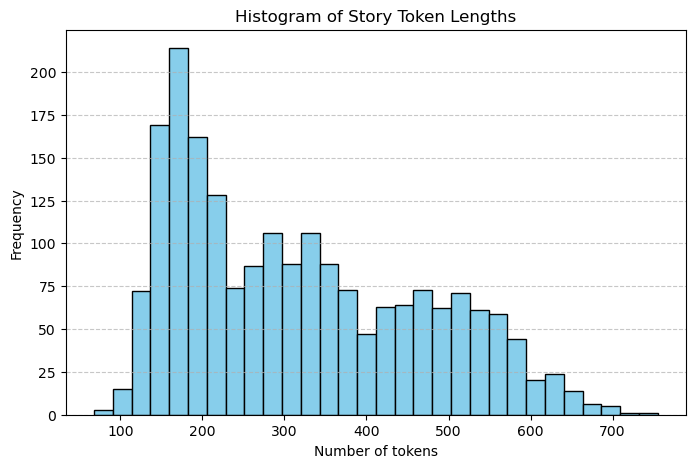

Mean length: 317.8 tokens
Max length: 755 tokens
Min length: 68 tokens


In [9]:
import matplotlib.pyplot as plt

# Calculate the length of each story in tokens
story_lengths = [len(tokenizer(text)["input_ids"]) for text in texts]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(story_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Story Token Lengths')
plt.xlabel('Number of tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Mean length: {sum(story_lengths)/len(story_lengths):.1f} tokens")
print(f"Max length: {max(story_lengths)} tokens")
print(f"Min length: {min(story_lengths)} tokens")

# Load Model with QLoRA Configuration

In [10]:
# Configure bitsandbytes for 4-bit quantization
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

In [11]:
# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load Llama 2 base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

model.config.use_cache = False
model.config.pretraining_tp = 1

Your GPU supports bfloat16: accelerate training with bf16=True


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


# Train the Model

In [13]:
from transformers import TrainerCallback

class SavePerEpochCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        model.save_pretrained(f"{new_model}_{epoch}")
        tokenizer.save_pretrained(f"{new_model}_{epoch}")
        print(f"Saved: {new_model}_{epoch}")

save_callback = SavePerEpochCallback()

# Set training parameters
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",
)

# Set supervised fine-tuning parameters
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=training_arguments,
    processing_class=tokenizer,
    callbacks=[save_callback],
)

# Train model
trainer.train()

# Save trained model and tokenizer together
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)
print(f"LoRA weights and tokenizer saved to: {new_model}")

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
25,1.526100
50,1.545200
75,1.370300
100,1.510900
125,1.341000
150,1.457100
175,1.325200
200,1.446200
225,1.304500
250,1.408600


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_1
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_2
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_3
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_4
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_5
LoRA weights and tokenizer saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune


# Merge LoRA Weights with Base Model

In [14]:
# Reload model in FP16 and merge it with LoRA weights
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map=device_map,
)
model = PeftModel.from_pretrained(base_model, new_model)
model = model.merge_and_unload()

# Reload tokenizer to save it
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

KeyboardInterrupt: 

# Test the Finetuned Model

In [ ]:
# Test the merged model with story generation
logging.set_verbosity(logging.CRITICAL)

print("Testing merged model:")
print("=" * 80)

# Test with a story-like prompt
prompt = "Once upon a time, there was a little"

pipe_test = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_length=300,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
)
result = pipe_test(prompt)
print(f"Prompt: {prompt}\n")
print(f"Generated story:\n{result[0]['generated_text']}")
print("\n" + "=" * 80)

In [ ]:
# Compare base model vs finetuned model
print("Loading base model (untrained)...")
base_model_compare = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map={"": 0},
)

tokenizer_compare = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer_compare.pad_token = tokenizer_compare.eos_token
tokenizer_compare.padding_side = "right"

logging.set_verbosity(logging.CRITICAL)

test_prompts = [
    "Once upon a time, there was a little",
    "The curious cat looked at the",
    "In a small village, there lived a",
]

print("\n" + "=" * 100)
print("COMPARISON: BASE MODEL vs FINETUNED MODEL")
print("=" * 100)

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n\nPrompt {i}: {prompt}")
    print("\n" + "-" * 100)
    
    # Base model response
    print("\nBASE MODEL (Before Finetuning):")
    print("-" * 100)
    pipe_base = pipeline(
        task="text-generation",
        model=base_model_compare,
        tokenizer=tokenizer_compare,
        max_length=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )
    result_base = pipe_base(prompt)
    print(result_base[0]['generated_text'])
    
    # Finetuned model response
    print("\n" + "-" * 100)
    print("FINETUNED MODEL (After Training on SimpleStories):")
    print("-" * 100)
    pipe_finetuned = pipeline(
        task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )
    result_finetuned = pipe_finetuned(prompt)
    print(result_finetuned[0]['generated_text'])
    print("\n" + "=" * 100)

print("\n\nComparison complete! The finetuned model should generate more story-like text.")